### Deterministic Ficticious Play in Static First Price

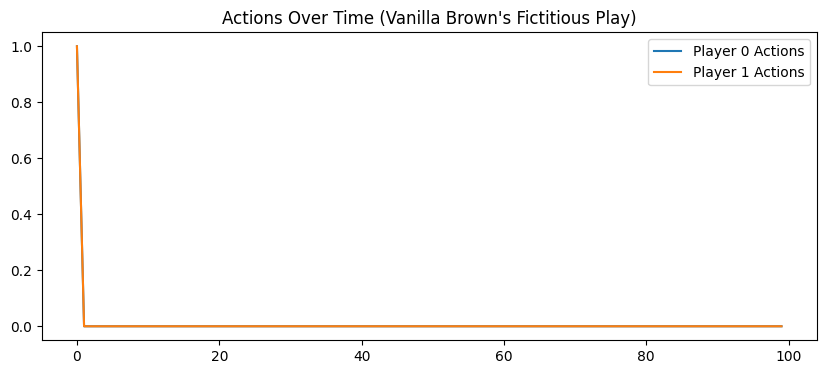

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define bids for high, mid, low
bids = np.array([0.0, 0.5, 1.0])

# All bidders value the item at 0.5
value = 0.5

# Reward matrix for first price auction with tie case giving 0.5 of possible reward
def reward_matrix(bidder_a, bidder_b):
    if bids[bidder_a] > bids[bidder_b]:
        return value - bids[bidder_a], 0
    elif bids[bidder_a] < bids[bidder_b]:
        return 0, value - bids[bidder_b]
    else:  # Tie case, half reward for both players
        return 0.5 * (value - bids[bidder_a]), 0.5 * (value - bids[bidder_b])

# Brown's Fictitious Play
def brown_fictitious_play_auction(player_idx, round_idx, history):
    if round_idx == 0:
        return np.random.choice([0, 1, 2])  # Random action in the first round

    opp_idx = 1 if player_idx == 0 else 0
    N = len(history)
    opp_actions = [history[i][opp_idx] for i in range(N)]  # Track opponent's past actions
    opp_probs = np.bincount(opp_actions, minlength=3) / N  # Empirical distribution of opponent's actions

    exp_payoffs = [np.dot([reward_matrix(i, opp_action)[player_idx] for opp_action in [0, 1, 2]], opp_probs) for i in [0, 1, 2]]
    best_response_idx = np.argmax(exp_payoffs)  # Best response based on expected payoffs
    
    return best_response_idx

# Simulate Brown's Fictitious Play
def run_fictitious_play(T=100):
    history = []
    for t in range(T):
        a0 = brown_fictitious_play_auction(0, t, history)  # Player 0
        a1 = brown_fictitious_play_auction(1, t, history)  # Player 1
        r0, r1 = reward_matrix(a0, a1)  # Get payoffs
        history.append([a0, a1, r0, r1])
    return history

# Run the simulation
history_brown = run_fictitious_play()

# Plot actions over time
actions_brown = np.array([[h[0], h[1]] for h in history_brown])

plt.figure(figsize=(10, 4))
plt.plot(actions_brown[:, 0], label='Player 0 Actions')
plt.plot(actions_brown[:, 1], label='Player 1 Actions')
plt.legend()
plt.title('Actions Over Time (Vanilla Brown\'s Fictitious Play)')
plt.show()


### Stochastic Ficticious Play in Static First Price

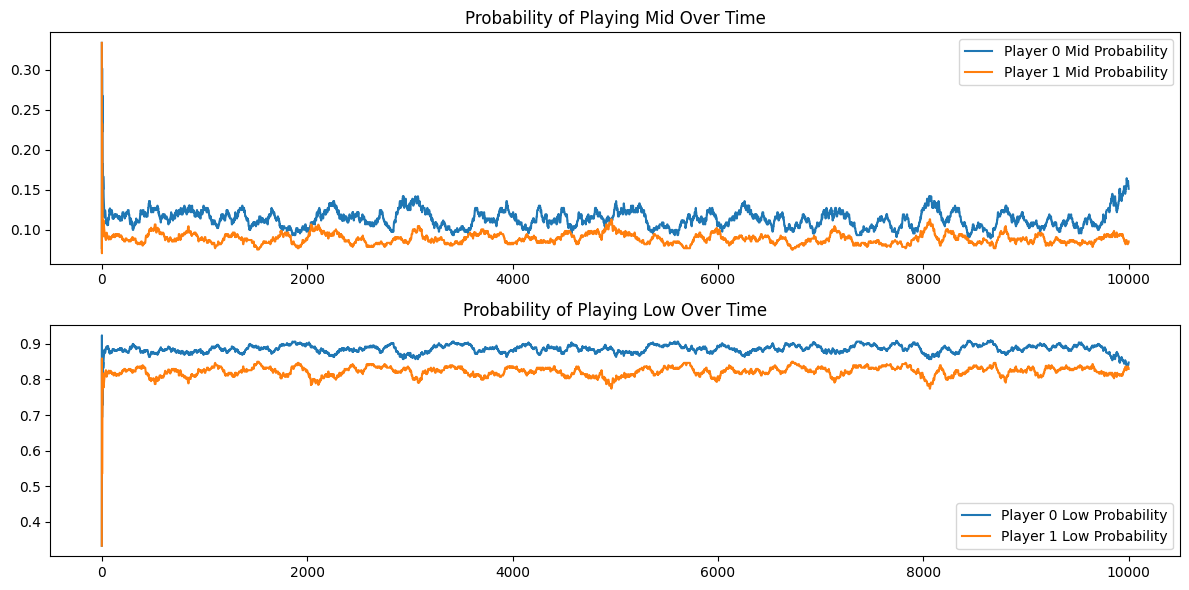

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define bids for high, mid, low
bids = np.array([0.0, 0.5, 1.0])

# All bidders value the item at 0.5
value = 0.5

# Reward matrix for first price auction with tie case giving 0.5 of possible reward
def reward_matrix(bidder_a, bidder_b):
    if bids[bidder_a] > bids[bidder_b]:
        return value - bids[bidder_a], 0
    elif bids[bidder_a] < bids[bidder_b]:
        return 0, value - bids[bidder_b]
    else:  # Tie case, half reward for both players
        return 0.5 * (value - bids[bidder_a]), 0.5 * (value - bids[bidder_b])

# Stochastic Fictitious Play using Softmax for action selection, focusing on last 100 rounds
def stoch_fictitious_play_auction(player_idx, round_idx, history, tau=1.0):
    if round_idx == 0:
        return np.random.choice([0, 1, 2]), [1/3, 1/3, 1/3]  # Random action in the first round

    opp_idx = 1 if player_idx == 0 else 0
    N = len(history)
    
    # Use only the last 100 rounds of history
    if N > 100:
        relevant_history = history[-100:]
    else:
        relevant_history = history

    opp_actions = [relevant_history[i][opp_idx] for i in range(len(relevant_history))]  # Track opponent's past actions
    opp_probs = np.bincount(opp_actions, minlength=3) / len(relevant_history)  # Empirical distribution of opponent's actions

    exp_payoffs = [np.dot([reward_matrix(i, opp_action)[player_idx] for opp_action in [0, 1, 2]], opp_probs) for i in [0, 1, 2]]
    
    # Softmax over expected payoffs to get action probabilities
    exp_payoffs = np.array(exp_payoffs)
    exp_payoffs_softmax = np.exp(exp_payoffs / tau) / np.sum(np.exp(exp_payoffs / tau))
    
    # Select action probabilistically using softmax probabilities
    return np.random.choice([0, 1, 2], p=exp_payoffs_softmax), exp_payoffs_softmax

# Simulate Stochastic Fictitious Play and track probabilities of playing mid or low
def run_stoch_fictitious_play(T=10000, tau=1.0):
    history = []
    mid_probs_p0, mid_probs_p1 = [], []
    low_probs_p0, low_probs_p1 = [], []
    
    for t in range(T):
        a0, prob0 = stoch_fictitious_play_auction(0, t, history, tau)  # Player 0
        a1, prob1 = stoch_fictitious_play_auction(1, t, history, tau)  # Player 1
        r0, r1 = reward_matrix(a0, a1)  # Get payoffs
        history.append([a0, a1, r0, r1])
        
        # Track probabilities for Player 0 and Player 1
        mid_probs_p0.append(prob0[1])  # Probability of playing mid for Player 0
        mid_probs_p1.append(prob1[1])  # Probability of playing mid for Player 1
        low_probs_p0.append(prob0[0])  # Probability of playing low for Player 0
        low_probs_p1.append(prob1[0])  # Probability of playing low for Player 1

    return mid_probs_p0, mid_probs_p1, low_probs_p0, low_probs_p1

# Run the stochastic simulation
mid_probs_p0, mid_probs_p1, low_probs_p0, low_probs_p1 = run_stoch_fictitious_play(tau=0.1)  # Set tau for randomness

# Plot probabilities of playing mid and low for both players
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(mid_probs_p0, label='Player 0 Mid Probability')
plt.plot(mid_probs_p1, label='Player 1 Mid Probability')
plt.legend()
plt.title('Probability of Playing Mid Over Time')

plt.subplot(2, 1, 2)
plt.plot(low_probs_p0, label='Player 0 Low Probability')
plt.plot(low_probs_p1, label='Player 1 Low Probability')
plt.legend()
plt.title('Probability of Playing Low Over Time')

plt.tight_layout()
plt.show()
